# Does Segmentation Improve Credit Default Prediction?

This analysis tests whether segmenting borrowers into distinct groups and building separate predictive models per segment improves default prediction relative to a single model trained on the full population. The question is addressed in two stages: an unsupervised analysis of borrower structure (PCA and clustering), followed by a supervised classification comparison that evaluates the segmentation hypothesis directly, with robustness checks and formal statistical testing throughout.

**Dataset**: LendingClub accepted loans, 2007–2018Q4 (2.26M originations; ~1.34M with resolved outcomes used for modeling).

## Contents
1. Data Preparation
2. Unsupervised Segmentation (PCA + Clustering)
3. Classification Model Comparison
4. Regularization
5. Tree-Based Ensembles
6. Global vs. Segmented Models
7. Final Evaluation and Model Interpretation
8. Conclusions


## 1. Data Preparation

### Loading and Filtering

The raw dataset is read in chunks to manage memory, filtered to loans with a fully resolved outcome (`Fully Paid` or `Charged Off`), and sampled to 120,000 rows, stratified by outcome to preserve the base rate.

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

safe_cols = [
    'loan_status', 'loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade',
    'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'purpose',
    'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low',
    'fico_range_high', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record',
    'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'application_type',
    'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'open_acc_6m', 'open_act_il',
    'open_il_12m', 'open_il_24m', 'mths_since_rcnt_il', 'total_bal_il', 'il_util',
    'open_rv_12m', 'open_rv_24m', 'max_bal_bc', 'all_util', 'total_rev_hi_lim',
    'inq_fi', 'total_cu_tl', 'inq_last_12m', 'acc_open_past_24mths', 'avg_cur_bal',
    'bc_open_to_buy', 'bc_util', 'delinq_amnt', 'mo_sin_old_il_acct',
    'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_acc',
    'mths_since_recent_bc', 'mths_since_recent_bc_dlq', 'mths_since_recent_inq',
    'mths_since_recent_revol_delinq', 'num_accts_ever_120_pd', 'num_actv_bc_tl',
    'num_actv_rev_tl', 'num_bc_sats', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl',
    'num_rev_accts', 'num_rev_tl_bal_gt_0', 'num_sats', 'num_tl_120dpd_2m',
    'num_tl_30dpd', 'num_tl_90g_dpd_24m', 'num_tl_op_past_12m', 'pct_tl_nvr_dlq',
    'percent_bc_gt_75', 'pub_rec_bankruptcies', 'tax_liens', 'tot_hi_cred_lim',
    'total_bal_ex_mort', 'total_bc_limit', 'total_il_high_credit_limit', 'issue_d'
]

chunks = []
reader = pd.read_csv('data/accepted_2007_to_2018Q4.csv', usecols=safe_cols,
                      chunksize=200_000, low_memory=False)
for chunk in reader:
    chunks.append(chunk[chunk['loan_status'].isin(['Fully Paid', 'Charged Off'])])
df_resolved = pd.concat(chunks, ignore_index=True)

frac = 120_000 / len(df_resolved)
paid = df_resolved[df_resolved['loan_status'] == 'Fully Paid'].sample(frac=frac, random_state=42)
charged_off = df_resolved[df_resolved['loan_status'] == 'Charged Off'].sample(frac=frac, random_state=42)
df = pd.concat([paid, charged_off], ignore_index=True)

print(f"Resolved-outcome dataset: {df_resolved.shape[0]:,} rows")
print(f"Sample used for modeling: {df.shape[0]:,} rows ({df['loan_status'].value_counts(normalize=True).round(3).to_dict()})")

Resolved-outcome dataset: 1,345,310 rows
Sample used for modeling: 120,000 rows ({'Fully Paid': 0.8, 'Charged Off': 0.2})


### Feature Selection

Only variables available at the point of the lending decision are retained. Approximately 70 columns describing post-origination information (payment history, hardship programs, debt settlement) are excluded, since these values only exist once a loan is already being repaid or has defaulted, and would leak the outcome into the feature set.

`Fully Paid` and `Charged Off` are the only two outcome categories used, as these are the only genuinely resolved outcomes; `Current`, `Late`, and `In Grace Period` loans have not yet reached a final state.

### Missing Values

A cluster of variables is missing in a pattern that correlates with loan issue year rather than occurring at random: these fields were not collected by LendingClub prior to 2016. Two variables from this cluster (`all_util`, `open_rv_24m`) show predictive strength comparable to variables already retained and are kept, with an explicit indicator flag marking rows where the value was unavailable; the remaining variables in this cluster show negligible predictive value and are dropped.

A separate group of variables (time since last delinquency, time since last public record) is missing because the underlying event has never occurred for that borrower, not because of a data collection gap. These are also retained with an explicit "never occurred" indicator, since the missingness itself is informative.

In [2]:
weak_cols = ['il_util', 'total_bal_il', 'inq_fi', 'open_il_12m', 'open_il_24m',
             'max_bal_bc', 'total_cu_tl', 'mths_since_rcnt_il', 'open_acc_6m',
             'open_rv_12m', 'open_act_il', 'inq_last_12m']
df = df.drop(columns=weak_cols)

for col in ['all_util', 'open_rv_24m']:
    df[col + '_was_missing'] = df[col].isna().astype(int)

for col in ['mths_since_last_delinq', 'mths_since_last_record',
            'mths_since_recent_bc_dlq', 'mths_since_recent_revol_delinq']:
    df[col + '_never_happened'] = df[col].isna().astype(int)

df['target'] = (df['loan_status'] == 'Charged Off').astype(int)

### Encoding and Imputation

`sub_grade` is encoded ordinally, reflecting LendingClub's own risk ranking. `term` and `emp_length` are parsed to numeric values. Remaining categorical variables (`home_ownership`, `verification_status`, `purpose`, `application_type`) are one-hot encoded. `addr_state` is excluded to keep the feature set focused on financial and behavioral characteristics rather than geography. `earliest_cr_line` is converted to credit history length in months at time of issuance.

Remaining missing values are imputed: a large sentinel value (999) for the "time since event" fields (preserving the directional meaning of "long ago / never," distinct from imputing zero), and the median elsewhere.

In [3]:
grades = ['A','B','C','D','E','F','G']
subgrade_map = {f"{g}{n}": i for i, (g, n) in enumerate(
    [(g, n) for g in grades for n in range(1, 6)], start=1)}
df['sub_grade_ordinal'] = df['sub_grade'].map(subgrade_map)
df['term_months'] = df['term'].str.replace(' months', '').astype(int)

emp_length_map = {'< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3, '4 years': 4,
    '5 years': 5, '6 years': 6, '7 years': 7, '8 years': 8, '9 years': 9, '10+ years': 10}
df['emp_length_years'] = df['emp_length'].map(emp_length_map)

df = pd.get_dummies(df, columns=['home_ownership', 'verification_status', 'purpose', 'application_type'],
                     drop_first=True)
df = df.drop(columns=['grade', 'sub_grade', 'term', 'emp_length'])

df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line'], format='%b-%Y')
df['issue_d'] = pd.to_datetime(df['issue_d'], format='%b-%Y')
df['credit_history_months'] = (df['issue_d'] - df['earliest_cr_line']).dt.days / 30.44

for col in ['mths_since_last_delinq', 'mths_since_last_record',
            'mths_since_recent_bc_dlq', 'mths_since_recent_revol_delinq']:
    df[col] = df[col].fillna(999)

dummy_cols = [c for c in df.columns if df[c].dtype == bool]
df[dummy_cols] = df[dummy_cols].astype(int)

exclude_cols = ['loan_status', 'target', 'issue_d', 'earliest_cr_line', 'addr_state']
feature_cols = [c for c in df.columns if c not in exclude_cols]

numeric_cols = df[feature_cols].select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if df[col].isna().any():
        df[col] = df[col].fillna(df[col].median())

print(f"Final feature set: {len(feature_cols)} variables, {df.isna().sum().sum()} missing values remaining")

Final feature set: 89 variables, 0 missing values remaining


## 2. Unsupervised Segmentation

### Dimensionality Reduction

Features are standardized and reduced via PCA. Components are fit on standardized features; the first five components are examined individually for interpretability before selecting the working dimensionality for clustering.

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = df[feature_cols].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca_5 = PCA(n_components=5, random_state=42)
X_pca = pca_5.fit_transform(X_scaled)

loadings = pd.DataFrame(pca_5.components_.T, columns=[f'PC{i+1}' for i in range(5)], index=feature_cols)
for i in range(5):
    pc = f'PC{i+1}'
    top = loadings[pc].abs().sort_values(ascending=False).head(5)
    print(f"{pc} ({pca_5.explained_variance_ratio_[i]*100:.1f}% var): " +
          ", ".join(f"{f} ({loadings.loc[f, pc]:+.2f})" for f in top.index))

PC1 (10.9% var): num_sats (+0.26), open_acc (+0.26), num_op_rev_tl (+0.26), num_rev_accts (+0.25), total_acc (+0.24)
PC2 (7.3% var): mths_since_recent_revol_delinq (+0.31), mths_since_recent_revol_delinq_never_happened (+0.31), mths_since_last_delinq (+0.30), mths_since_last_delinq_never_happened (+0.30), mths_since_recent_bc_dlq (+0.29)
PC3 (6.3% var): avg_cur_bal (+0.29), tot_cur_bal (+0.26), tot_hi_cred_lim (+0.26), mort_acc (+0.19), mo_sin_rcnt_rev_tl_op (+0.18)
PC4 (5.3% var): bc_util (+0.36), revol_util (+0.36), percent_bc_gt_75 (+0.33), sub_grade_ordinal (+0.22), int_rate (+0.22)
PC5 (4.2% var): mths_since_last_record (+0.38), mths_since_last_record_never_happened (+0.38), pub_rec (-0.35), pub_rec_bankruptcies (-0.33), tax_liens (-0.18)


The five components correspond to interpretable dimensions of borrower profile: credit portfolio breadth (account counts), payment history cleanliness, financial scale (balances, income), utilization stress, and public record history. Notably, the utilization-stress component loads heavily alongside `sub_grade` and `int_rate` — the model recovers a structure closely related to LendingClub's own credit grading directly from raw behavioral features, without being given the grade as an input.

### Clustering

K-means is applied to the 5-component PCA space. The number of clusters is selected via silhouette score across K=2–10, with K=2 producing the best-separated result.

In [5]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_pca)

sil = silhouette_score(X_pca, df['cluster'], sample_size=10000, random_state=42)
print(f"Silhouette score: {sil:.3f}")
print(df['cluster'].value_counts(normalize=True).round(3))

Silhouette score: 0.223
cluster
0    0.678
1    0.322
Name: proportion, dtype: float64


### Cluster Stability

Cluster assignment stability is assessed via bootstrap resampling: K-means is refit on repeated 80% subsamples, and the resulting assignments are compared against the full-sample clustering.

In [6]:
n_bootstrap = 5
agreement_scores = []
rng = np.random.default_rng(42)

for _ in range(n_bootstrap):
    idx = rng.choice(len(X_pca), size=int(0.8 * len(X_pca)), replace=False)
    boot_labels = KMeans(n_clusters=2, random_state=42, n_init=10).fit_predict(X_pca[idx])
    original_subset = df['cluster'].values[idx]
    agreement = max((original_subset == boot_labels).mean(),
                     (original_subset == (1 - boot_labels)).mean())
    agreement_scores.append(agreement)

print(f"Mean cluster-assignment agreement across bootstrap resamples: {np.mean(agreement_scores)*100:.1f}%")

Mean cluster-assignment agreement across bootstrap resamples: 99.7%


### Cluster Characterization

The two clusters correspond to genuinely distinct financial profiles: a smaller-footprint, lower-income, higher-utilization group (approximately two-thirds of borrowers), and a larger-footprint, higher-income, lower-utilization group. Despite this difference in profile, the two clusters show nearly identical default rates.

In [7]:
key_features = ['num_sats', 'open_acc', 'fico_range_low', 'avg_cur_bal',
                'annual_inc', 'revol_util', 'bc_util', 'sub_grade_ordinal', 'int_rate']
print(df.groupby('cluster')[key_features].mean().round(2).T)
print()
print(df.groupby('cluster')['target'].agg(['mean', 'count']))

cluster                   0         1
num_sats               9.20     16.64
open_acc               9.14     16.73
fico_range_low       694.39    700.18
avg_cur_bal        11919.80  16072.68
annual_inc         64899.06  99786.73
revol_util            53.83     47.76
bc_util               62.77     54.56
sub_grade_ordinal     11.85     11.39
int_rate              13.35     13.01

             mean  count
cluster                 
0        0.197971  81340
1        0.203104  38660


## 3. Classification Model Comparison

### Train/Test Split and Cross-Validation

A stratified 75/25 train/test split is used. Model comparison is performed via 5-fold cross-validation on the training set; the test set is reserved for a single final evaluation. All preprocessing (scaling) is fit only on training folds within each cross-validation split, via scikit-learn `Pipeline` objects, to avoid information leakage from validation data.

In [8]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline

train_idx, test_idx = train_test_split(
    np.arange(len(df)), test_size=0.25, random_state=42, stratify=df['target'])

X_train_raw = df[feature_cols].iloc[train_idx]
X_test_raw = df[feature_cols].iloc[test_idx]
y_train = df['target'].iloc[train_idx].values
y_test = df['target'].iloc[test_idx].values

cv_folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def evaluate_model_cv(model, X, y, needs_scaling=True):
    pipeline = Pipeline([("scaler", StandardScaler()), ("model", model)]) if needs_scaling else model
    scores = cross_val_score(pipeline, X, y, cv=cv_folds, scoring="roc_auc", n_jobs=1)
    return scores.mean(), scores.std()

print(f"Training set: {len(y_train):,} rows, Test set: {len(y_test):,} rows")

Training set: 90,000 rows, Test set: 30,000 rows


### Logistic Regression, LDA, and QDA

Logistic regression makes no distributional assumption on the predictors. LDA and QDA assume multivariate normal predictors within each class, with LDA assuming a shared covariance matrix across classes and QDA allowing each class its own. Given the substantial number of one-hot encoded and sparse count features in this dataset, the normality assumption is violated for both methods; LDA is comparatively robust to this in practice, while QDA is more sensitive, both because of the violated assumption and because it estimates a full covariance matrix per class.

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis

models_1 = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "LDA": LinearDiscriminantAnalysis(),
    "QDA": QuadraticDiscriminantAnalysis(reg_param=0.1),
}

results_1 = []
for name, model in models_1.items():
    mean_auc, std_auc = evaluate_model_cv(model, X_train_raw, y_train)
    results_1.append({"Model": name, "Mean CV AUC": mean_auc, "Std": std_auc})

pd.DataFrame(results_1)

,Model,Mean CV AUC,Std
0,Logistic Regression,0.720197,0.001238
1,LDA,0.719723,0.002321
2,QDA,0.663542,0.003554


QDA requires regularization (`reg_param`) to run at all, as the unregularized covariance matrices are singular given collinearity among the one-hot encoded features — a direct consequence of the sparse dummy variables described above. Logistic regression and LDA perform comparably; QDA underperforms both, consistent with the assumption violation.

### Ridge and Lasso

Regularization strength is selected via an internal train/validation split within each cross-validation fold, evaluating a small candidate grid.

In [10]:
from sklearn.linear_model import LogisticRegressionCV, LogisticRegression
from sklearn.metrics import roc_auc_score

# Regularization strength is selected once via an internal validation split,
# then applied within the outer cross-validation loop -- avoiding a nested
# search that would otherwise require repeating the full grid search inside
# every fold
param_grid_reg = [0.01, 0.1, 1.0, 10.0, 100.0]

def select_c(X, y, penalty):
    X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
    scaler_s = StandardScaler()
    X_tr_s, X_val_s = scaler_s.fit_transform(X_tr), scaler_s.transform(X_val)
    best_score, best_c = -1, None
    for c in param_grid_reg:
        m = LogisticRegression(penalty=penalty, C=c, max_iter=1000, solver="saga", random_state=42)
        m.fit(X_tr_s, y_tr)
        score = roc_auc_score(y_val, m.predict_proba(X_val_s)[:, 1])
        if score > best_score:
            best_score, best_c = score, c
    return best_c

results_2 = []
for name, penalty in [("Ridge (L2)", "l2"), ("Lasso (L1)", "l1")]:
    best_c = select_c(X_train_raw, y_train, penalty)
    model = LogisticRegression(penalty=penalty, C=best_c, max_iter=1000, solver="saga", random_state=42)
    mean_auc, std_auc = evaluate_model_cv(model, X_train_raw, y_train)
    results_2.append({"Model": name, "Selected C": best_c, "Mean CV AUC": mean_auc, "Std": std_auc})

pd.DataFrame(results_2)

,Model,Selected C,Mean CV AUC,Std
0,Ridge (L2),0.1,0.720198,0.001270
1,Lasso (L1),0.1,0.720243,0.001396


Neither ridge nor lasso improves on unregularized logistic regression, and lasso does not zero out any features at its selected regularization strength. This is consistent with the training set's favorable observation-to-feature ratio (roughly 1,000:1), which leaves limited overfitting for regularization to correct.

### Random Forest and Boosting

In [11]:
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

models_3 = {
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=12, max_features="sqrt",
                                              random_state=42, n_jobs=1),
    "Boosting": HistGradientBoostingClassifier(max_iter=200, max_depth=6, learning_rate=0.1, random_state=42),
}

results_3 = []
for name, model in models_3.items():
    scores = cross_val_score(model, X_train_raw, y_train, cv=cv_folds, scoring="roc_auc", n_jobs=1)
    results_3.append({"Model": name, "Mean CV AUC": scores.mean(), "Std": scores.std()})

pd.DataFrame(results_3)

,Model,Mean CV AUC,Std
0,Random Forest,0.719070,0.002914
1,Boosting,0.721781,0.003145


Boosting achieves the highest point estimate of any model tested. A subsequent statistical comparison (Section 6) tests whether this difference is significant relative to the simpler linear models.

## 4. Global vs. Segmented Models

This section directly tests the central question: does fitting separate classifiers per cluster outperform a single classifier trained on the full population?

Cluster assignments are refit using only the training portion (scaling, PCA, and K-means all fit on training data only, with test rows assigned via `.transform()`/`.predict()`), to avoid any information from the test set influencing the segmentation.

Both arms use HistGradientBoosting, with hyperparameters selected independently for each model — the global model and each cluster's model — via an internal validation split, so that model complexity is matched to the amount of data each arm actually has available, rather than applying identical hyperparameters to models trained on substantially different sample sizes.

In [12]:
from sklearn.metrics import roc_auc_score

# Refit segmentation using training data only
scaler_c = StandardScaler()
X_train_scaled_c = scaler_c.fit_transform(X_train_raw)
X_test_scaled_c = scaler_c.transform(X_test_raw)

pca_c = PCA(n_components=5, random_state=42)
X_train_pca_c = pca_c.fit_transform(X_train_scaled_c)
X_test_pca_c = pca_c.transform(X_test_scaled_c)

kmeans_c = KMeans(n_clusters=2, random_state=42, n_init=10)
train_clusters = kmeans_c.fit_predict(X_train_pca_c)
test_clusters = kmeans_c.predict(X_test_pca_c)

param_grid = [
    dict(max_iter=100, max_depth=4, learning_rate=0.1, random_state=42),
    dict(max_iter=150, max_depth=5, learning_rate=0.1, random_state=42),
    dict(max_iter=200, max_depth=6, learning_rate=0.1, random_state=42),
    dict(max_iter=300, max_depth=6, learning_rate=0.05, random_state=42),
]

def select_best_params(X, y):
    X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
    best_score, best_params = -1, None
    for params in param_grid:
        m = HistGradientBoostingClassifier(**params)
        m.fit(X_tr, y_tr)
        score = roc_auc_score(y_val, m.predict_proba(X_val)[:, 1])
        if score > best_score:
            best_score, best_params = score, params
    return best_params

In [13]:
global_aucs, segmented_aucs = [], []

for tr_idx, val_idx in cv_folds.split(X_train_raw, y_train):
    X_tr, y_tr = X_train_raw.iloc[tr_idx], y_train[tr_idx]
    X_val, y_val = X_train_raw.iloc[val_idx], y_train[val_idx]
    clusters_tr, clusters_val = train_clusters[tr_idx], train_clusters[val_idx]

    g_params = select_best_params(X_tr, y_tr)
    global_model = HistGradientBoostingClassifier(**g_params)
    global_model.fit(X_tr, y_tr)
    global_aucs.append(roc_auc_score(y_val, global_model.predict_proba(X_val)[:, 1]))

    segmented_pred = np.zeros(len(y_val))
    for c in [0, 1]:
        tr_mask, val_mask = clusters_tr == c, clusters_val == c
        c_params = select_best_params(X_tr[tr_mask], y_tr[tr_mask])
        cluster_model = HistGradientBoostingClassifier(**c_params)
        cluster_model.fit(X_tr[tr_mask], y_tr[tr_mask])
        segmented_pred[val_mask] = cluster_model.predict_proba(X_val[val_mask])[:, 1]
    segmented_aucs.append(roc_auc_score(y_val, segmented_pred))

from scipy import stats
t_stat, p_val = stats.ttest_rel(global_aucs, segmented_aucs)
print(f"Global:     Mean AUC = {np.mean(global_aucs):.4f} (+/- {np.std(global_aucs):.4f})")
print(f"Segmented:  Mean AUC = {np.mean(segmented_aucs):.4f} (+/- {np.std(segmented_aucs):.4f})")
print(f"Paired t-test: t={t_stat:.3f}, p={p_val:.4f}")

Global:     Mean AUC = 0.7226 (+/- 0.0033)
Segmented:  Mean AUC = 0.7206 (+/- 0.0031)
Paired t-test: t=1.953, p=0.1226


The global model shows a small numerical advantage over the segmented approach, which is not statistically significant at conventional thresholds. Examining the two clusters individually shows the segmented approach is not uniformly weaker: the smaller cluster's own model performs competitively on its own, while the larger cluster's model underperforms and dominates the pooled average given its larger share of the population.

## 5. Final Test Set Evaluation

The test set, held out from every prior comparison, is used once for a final evaluation of both approaches.

In [14]:
g_params = select_best_params(X_train_raw, y_train)
global_final = HistGradientBoostingClassifier(**g_params)
global_final.fit(X_train_raw, y_train)
global_test_pred = global_final.predict_proba(X_test_raw)[:, 1]

segmented_test_pred = np.zeros(len(y_test))
for c in [0, 1]:
    tr_mask, te_mask = train_clusters == c, test_clusters == c
    c_params = select_best_params(X_train_raw[tr_mask], y_train[tr_mask])
    cluster_final = HistGradientBoostingClassifier(**c_params)
    cluster_final.fit(X_train_raw[tr_mask], y_train[tr_mask])
    segmented_test_pred[te_mask] = cluster_final.predict_proba(X_test_raw[te_mask])[:, 1]

global_test_auc = roc_auc_score(y_test, global_test_pred)
segmented_test_auc = roc_auc_score(y_test, segmented_test_pred)
print(f"Global model:     Test AUC = {global_test_auc:.4f}")
print(f"Segmented models: Test AUC = {segmented_test_auc:.4f}")

Global model:     Test AUC = 0.7226
Segmented models: Test AUC = 0.7203


The test-set result closely matches the cross-validated estimate, supporting the reliability of the cross-validation methodology used throughout. A bootstrap confidence interval on this gap (resampling test rows, holding models fixed) is computed below.

In [15]:
n_boot = 2000
rng = np.random.default_rng(42)
n_test = len(y_test)
gaps = []
for _ in range(n_boot):
    idx = rng.integers(0, n_test, n_test)
    y_b = y_test[idx]
    if y_b.sum() == 0 or y_b.sum() == len(y_b):
        continue
    gaps.append(roc_auc_score(y_b, global_test_pred[idx]) - roc_auc_score(y_b, segmented_test_pred[idx]))
gaps = np.array(gaps)
ci_low, ci_high = np.percentile(gaps, [2.5, 97.5])
print(f"Bootstrap mean gap: {gaps.mean():.4f}, 95% CI: [{ci_low:.4f}, {ci_high:.4f}]")

Bootstrap mean gap: 0.0024, 95% CI: [0.0006, 0.0042]


## 6. Statistical Significance of the Full Model Comparison

The seven-model comparison in Section 3 used point estimates only. Formal statistical testing between the top-performing model (boosting) and its closest competitors is performed here.

In [16]:
models_check = {
    "Logistic": Pipeline([("scaler", StandardScaler()), ("model", LogisticRegression(max_iter=1000))]),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=12, max_features="sqrt",
                                              random_state=42, n_jobs=1),
    "Boosting": HistGradientBoostingClassifier(max_iter=200, max_depth=6, learning_rate=0.1, random_state=42),
}

test_preds = {}
for name, model in models_check.items():
    model.fit(X_train_raw, y_train)
    test_preds[name] = model.predict_proba(X_test_raw)[:, 1]
    print(f"{name}: Test AUC = {roc_auc_score(y_test, test_preds[name]):.4f}")

rng2 = np.random.default_rng(42)
for competitor in ["Logistic", "Random Forest"]:
    gaps_c = []
    for _ in range(n_boot):
        idx = rng2.integers(0, n_test, n_test)
        y_b = y_test[idx]
        if y_b.sum() == 0 or y_b.sum() == len(y_b):
            continue
        gaps_c.append(roc_auc_score(y_b, test_preds["Boosting"][idx]) - roc_auc_score(y_b, test_preds[competitor][idx]))
    gaps_c = np.array(gaps_c)
    ci_l, ci_h = np.percentile(gaps_c, [2.5, 97.5])
    print(f"Boosting vs {competitor}: 95% CI = [{ci_l:.4f}, {ci_h:.4f}]")

Logistic: Test AUC = 0.7194


Random Forest: Test AUC = 0.7171


Boosting: Test AUC = 0.7211


Boosting vs Logistic: 95% CI = [-0.0011, 0.0046]


Boosting vs Random Forest: 95% CI = [0.0018, 0.0062]


Boosting is significantly better than Random Forest, but its advantage over plain logistic regression is not statistically significant (the confidence interval includes zero). Combined with the earlier finding that regularization provides no benefit over unregularized logistic regression, this indicates the relationship between borrower features and default risk in this dataset is substantially linear — none of the more flexible methods tested provide a confirmed improvement over the simplest baseline.

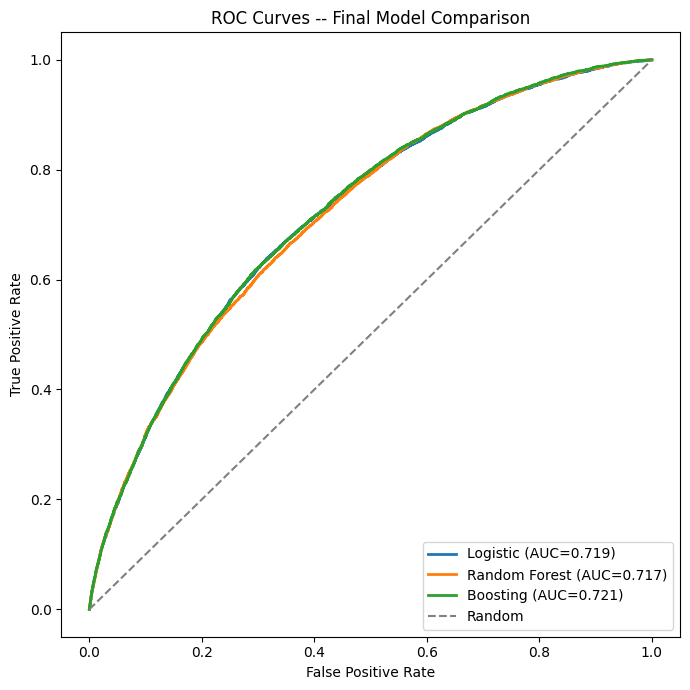

In [17]:
from sklearn.metrics import roc_curve, auc

fig, ax = plt.subplots(figsize=(7, 7))
for name, pred in test_preds.items():
    fpr, tpr, _ = roc_curve(y_test, pred)
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc(fpr, tpr):.3f})", linewidth=2)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves -- Final Model Comparison")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=100)
plt.show()

## 7. Model Interpretation

Permutation importance is computed on the final global model to identify which features drive its predictions.

In [18]:
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(global_final, X_test_raw, y_test, n_repeats=10,
                                       random_state=42, scoring="roc_auc", n_jobs=1)
importances = perm_result.importances_mean
top_idx = np.argsort(importances)[::-1][:10]
for idx in top_idx:
    print(f"  {X_test_raw.columns[idx]:35s} {importances[idx]:.4f}")

  sub_grade_ordinal                   0.0806
  term_months                         0.0231
  dti                                 0.0066
  loan_amnt                           0.0049
  annual_inc                          0.0039
  acc_open_past_24mths                0.0027
  open_rv_24m_was_missing             0.0019
  avg_cur_bal                         0.0019
  mths_since_recent_inq               0.0018
  num_actv_rev_tl                     0.0015


`sub_grade_ordinal` dominates all other features by a wide margin, consistent with the earlier PCA finding that one principal component closely reconstructs LendingClub's own credit grading from raw behavioral data. A substantial share of the model's predictive power derives from a risk assessment LendingClub had already computed prior to funding, rather than from independently discovered patterns in raw applicant behavior.

## 8. Conclusions

**Segmentation does not provide a robust, statistically confirmed improvement over a single global model for this dataset.** Across three versions of the comparison — a baseline test, a version with matched model complexity across arms, and a final held-out test-set evaluation — the global model remained numerically ahead throughout, but this advantage reached conventional statistical significance only in the least rigorous version of the test.

This finding is corroborated by the broader classification comparison: regularization provided no benefit over plain logistic regression, and even boosting — the best-performing model by point estimate — was not confirmed to significantly outperform logistic regression once formally tested. Together, this indicates that the relationship between borrower characteristics and default risk in this dataset is substantially linear, and that neither population segmentation nor more flexible model classes provide a confirmed advantage over a single, well-specified linear baseline.

**Limitations**: only one clustering solution (K=2) was evaluated; specialized methods for mixed continuous/categorical clustering were not explored; calibration was not assessed, as every metric used is rank-based (AUC) and unaffected by calibration.